In [2]:
#importing libraries here
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.utils.validation import check_is_fitted

In [3]:
#In this project, we are working for a client who wants to create a model
#  that can predict the price of apartments in the city of Buenos Aires — with
#  a focus on apartments that cost less than $400,000 USD.WQU WorldQuant University Applied Data Science Lab QQQQ

def wrangle(path):
    df = pd.read_csv(path)

    plece_names_data = df["place_with_parent_names"].str.contains("Capital Federal")
    apartment_data = df["property_type"] == "apartment"
    price_specific_data = df["price_aprox_usd"] < 400000

    df = df[apartment_data & plece_names_data & price_specific_data]

    # remove outliers
    low, high = df["surface_covered_in_m2"].quantile([0.1, 0.9])
    filteredout_outliers = df["surface_covered_in_m2"].between(low, high)
    df = df[filteredout_outliers]
    
    return df

In [124]:
df = wrangle("data/buenos-aires-real-estate-1.csv")
df.shape

(1343, 16)

Text(0.5, 1.0, 'Distribution of Apartment Sizes')

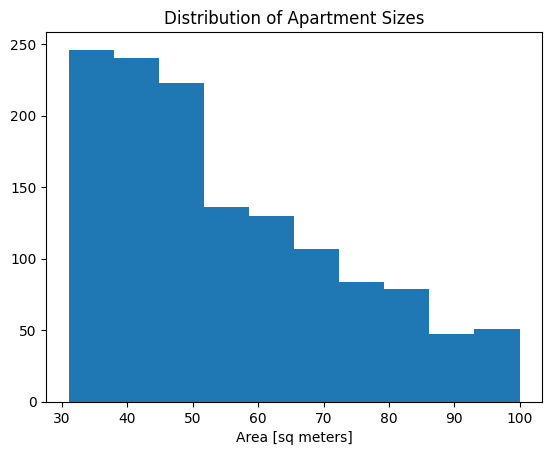

In [125]:
plt.hist(df["surface_covered_in_m2"])
plt.xlabel("Area [sq meters]")
plt.title("Distribution of Apartment Sizes")

np.float64(0.6868188329865078)

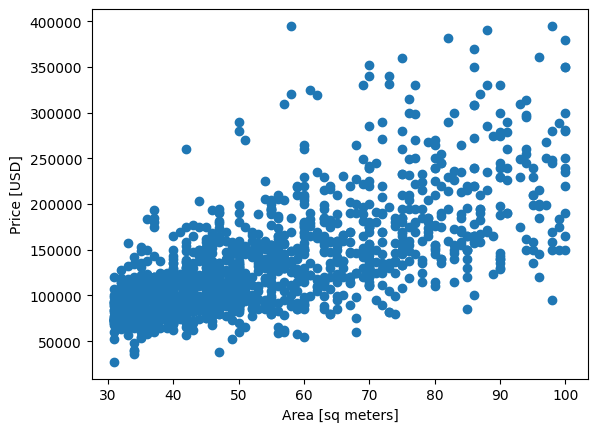

In [126]:
plt.scatter(df["surface_covered_in_m2"], df["price_aprox_usd"])
plt.xlabel("Area [sq meters]")
plt.ylabel("Price [USD]")
df["surface_covered_in_m2"].corr(df["price_aprox_usd"])

In [127]:
feature = ["surface_covered_in_m2"]
target = "price_aprox_usd"

X_train = df[feature]
y_train = df[target]

In [128]:
# setting the baseline first
y_mean = y_train.mean()
y_pre_baseline = [y_mean] * len(y_train)

print(f'mean absolute error is {round(mean_absolute_error(y_train, y_pre_baseline), 2)}')

mean absolute error is 45199.46


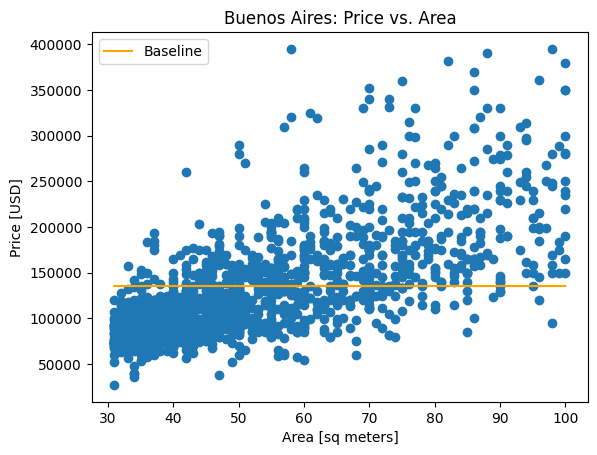

In [129]:
# the performace of our baseline

plt.plot(X_train["surface_covered_in_m2"], y_pre_baseline, color="orange", label="Baseline")
plt.scatter(X_train, y_train)
plt.xlabel("Area [sq meters]")
plt.ylabel("Price [USD]")
plt.title("Buenos Aires: Price vs. Area")
plt.legend()

In [130]:
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [131]:
y_pred_values = pd.Series(model.predict(X_train))
df

print(f'mean absolute error {round(mean_absolute_error(y_train, y_pred_values), 2)}')

mean absolute error 31248.26


In [143]:
X_test = pd.read_csv("data/buenos-aires-test-features.csv")
X_test.head()

,surface_covered_in_m2,lat,lon,neighborhood
0,47.0,-34.615310,-58.361983,Puerto Madero
1,55.0,-34.547298,-58.462705,Nuñez
2,34.0,-34.617762,-58.383662,Monserrat
3,34.0,-34.639925,-58.438406,Parque Chacabuco
4,42.0,-34.611495,-58.442359,Caballito


In [149]:
X_test = pd.read_csv("data/buenos-aires-test-features.csv")[feature]
y_pre_test = pd.Series(model.predict(X_test).round(2))
X_test["predicted_price"] = y_pre_test

X_test.head()

,surface_covered_in_m2,predicted_price
0,47.0,117330.06
1,55.0,135355.04
2,34.0,88039.47
3,34.0,88039.47
4,42.0,106064.45


In [156]:
#Creating eqaution of the line y = B0 + B1*x

coefficient = model.coef_[0].round(2)
coefficient

intercept = model.intercept_.round(2)
print(f"apartment_price = {intercept} + {coefficient} * surface_covered") 

apartment_price = 11433.31 + 2253.12 * surface_covered


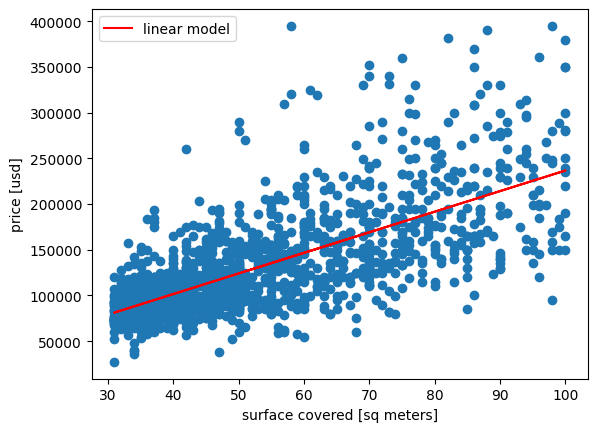

In [165]:
# Final plot indication the line of best fit

plt.plot(X_train, model.predict(X_train), color="red", label="linear model")
plt.scatter(X_train, y_train)
plt.xlabel("surface covered [sq meters]")
plt.ylabel("price [usd]")
plt.legend()
